In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

TRAIN_IMG_DIR = 'images_data/train/'
train_df = pd.read_csv('train_data.csv')
train_df

,image_id,label,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax
0,img_0000,0,-1.0,-1.0,-1.0,-1.0
1,img_0001,0,-1.0,-1.0,-1.0,-1.0
2,img_0002,1,95.0,326.0,249.0,512.0
3,img_0003,0,-1.0,-1.0,-1.0,-1.0
4,img_0004,1,198.0,82.0,374.0,299.0
...,...,...,...,...,...,...
795,img_0995,0,-1.0,-1.0,-1.0,-1.0
796,img_0996,0,-1.0,-1.0,-1.0,-1.0
797,img_0997,1,85.0,104.0,247.0,317.0
798,img_0998,0,-1.0,-1.0,-1.0,-1.0


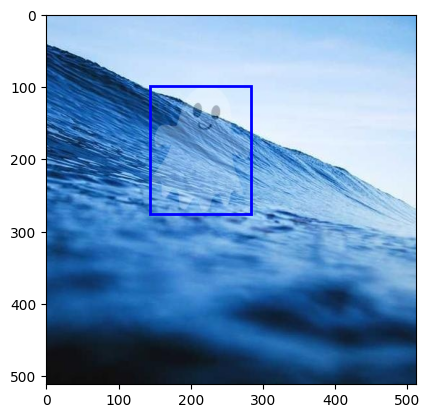

In [3]:
def show_img(row):
    if row['label'] == 0:
        return None
    
    img = Image.open(TRAIN_IMG_DIR + row['image_id'] + '.jpg')
    fig, ax = plt.subplots()
    x = row['bbox_xmin']
    y = row['bbox_ymin']
    w = x - row['bbox_xmax']
    h = y - row['bbox_ymax']
    rect = Rectangle((x ,y), -w, -h, linewidth=2, facecolor='none', edgecolor='blue')
    ax.add_patch(rect)
    plt.imshow(img)

show_img(train_df[train_df['label'] == 1].iloc[7])

In [4]:
train_df["image_id"].unique().tolist()

['img_0000',
 'img_0001',
 'img_0002',
 'img_0003',
 'img_0004',
 'img_0005',
 'img_0006',
 'img_0007',
 'img_0008',
 'img_0009',
 'img_0010',
 'img_0011',
 'img_0013',
 'img_0014',
 'img_0015',
 'img_0016',
 'img_0019',
 'img_0020',
 'img_0021',
 'img_0022',
 'img_0023',
 'img_0024',
 'img_0026',
 'img_0027',
 'img_0028',
 'img_0029',
 'img_0030',
 'img_0031',
 'img_0032',
 'img_0033',
 'img_0034',
 'img_0035',
 'img_0036',
 'img_0037',
 'img_0038',
 'img_0039',
 'img_0040',
 'img_0041',
 'img_0042',
 'img_0045',
 'img_0047',
 'img_0048',
 'img_0049',
 'img_0050',
 'img_0052',
 'img_0053',
 'img_0056',
 'img_0058',
 'img_0059',
 'img_0061',
 'img_0062',
 'img_0063',
 'img_0064',
 'img_0065',
 'img_0067',
 'img_0069',
 'img_0071',
 'img_0072',
 'img_0074',
 'img_0075',
 'img_0076',
 'img_0077',
 'img_0078',
 'img_0079',
 'img_0081',
 'img_0082',
 'img_0083',
 'img_0084',
 'img_0085',
 'img_0086',
 'img_0087',
 'img_0088',
 'img_0089',
 'img_0090',
 'img_0091',
 'img_0092',
 'img_0093',

In [5]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import shutil

IMAGE_DIR = Path("images_data/train")
OUTPUT_DIR = Path("yolo_dataset")

TRAIN_IMAGES = OUTPUT_DIR / "images/train"
VAL_IMAGES = OUTPUT_DIR / "images/val"

TRAIN_LABELS = OUTPUT_DIR / "labels/train"
VAL_LABELS = OUTPUT_DIR / "labels/val"

for d in [
    TRAIN_IMAGES,
    VAL_IMAGES,
    TRAIN_LABELS,
    VAL_LABELS,
]:
    d.mkdir(parents=True, exist_ok=True)

image_ids = train_df[train_df['label'] == 1]["image_id"].unique().tolist()

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.1
)

train_ids = set(train_ids)
val_ids = set(val_ids)

for image_id in image_ids:
    image_path = IMAGE_DIR / (image_id + '.jpg')

    img = Image.open(image_path)
    width, height = img.size

    yolo_lines = []
    
    row = train_df[train_df['image_id'] == image_id].iloc[0]
    xmin = row["bbox_xmin"]
    ymin = row["bbox_ymin"]
    xmax = row["bbox_xmax"]
    ymax = row["bbox_ymax"]

    x_center = ((xmin + xmax) / 2) / width
    y_center = ((ymin + ymax) / 2) / height

    box_width = (xmax - xmin) / width
    box_height = (ymax - ymin) / height

    class_id = 0

    yolo_lines.append(
        f"{class_id} {x_center} {y_center} {box_width} {box_height}"
    )
    # print(box_width)
    # print(x_center)
    # print(f"{class_id} {x_center} {y_center} {box_width} {box_height}")

    if image_id in train_ids:
        target_image = TRAIN_IMAGES / (image_id + '.jpg')
        target_label = TRAIN_LABELS / f"{Path(image_id).stem}.txt"
    else:
        target_image = VAL_IMAGES / (image_id + '.jpg')
        target_label = VAL_LABELS / f"{Path(image_id).stem}.txt"

    shutil.copy(image_path, target_image)

    with open(target_label, "w") as f:
        f.write("\n".join(yolo_lines))

yaml_content = """
path: yolo_dataset

train: images/train
val: images/val

names:
  0: object
"""

with open(OUTPUT_DIR / "data.yaml", "w") as f:
    f.write(yaml_content)

print("YOLO dataset created successfully.")

YOLO dataset created successfully.


In [6]:
from ultralytics import YOLO

model = YOLO('yolo26n.pt')

model.train(data='yolo_dataset/data.yaml', epochs=50, imgsz=512, batch=16)

Ultralytics 8.4.56  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001E805760A50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [ ]:
results = model.predict(source='images_data/inference/', conf=0.5)

rows = []

for result in results:
    image_name = Path(result.path).name

    for box in result.boxes:
        xmin, ymin, xmax, ymax = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls = int(box.cls[0].item())

        rows.append({
            "image_id": image_name,
            "class_id": cls,
            "confidence": conf,
            "bbox_xmin": xmin,
            "bbox_ymin": ymin,
            "bbox_xmax": xmax,
            "bbox_ymax": ymax,
        })

df = pd.DataFrame(rows)

df.to_csv("predictions.csv", index=False)

print(df.head())


image 1/200 c:\Users\raian\source\repos\AI\IOAI_prep\romania\nitro\ghost_object_detection\images_data\inference\img_0012.jpg: 512x512 (no detections), 10.6ms
image 2/200 c:\Users\raian\source\repos\AI\IOAI_prep\romania\nitro\ghost_object_detection\images_data\inference\img_0017.jpg: 512x512 (no detections), 8.8ms
image 3/200 c:\Users\raian\source\repos\AI\IOAI_prep\romania\nitro\ghost_object_detection\images_data\inference\img_0018.jpg: 512x512 (no detections), 11.0ms
image 4/200 c:\Users\raian\source\repos\AI\IOAI_prep\romania\nitro\ghost_object_detection\images_data\inference\img_0025.jpg: 512x512 (no detections), 16.3ms
image 5/200 c:\Users\raian\source\repos\AI\IOAI_prep\romania\nitro\ghost_object_detection\images_data\inference\img_0043.jpg: 512x512 (no detections), 12.5ms
image 6/200 c:\Users\raian\source\repos\AI\IOAI_prep\romania\nitro\ghost_object_detection\images_data\inference\img_0044.jpg: 512x512 1 object, 16.0ms
image 7/200 c:\Users\raian\source\repos\AI\IOAI_prep\romani

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'object'}
 obb: None
 orig_img: array([[[119, 141, 166],
         [129, 151, 176],
         [140, 162, 187],
         ...,
         [ 46,  74,  91],
         [ 51,  81,  98],
         [ 59,  89, 106]],
 
        [[115, 137, 162],
         [125, 147, 172],
         [136, 158, 183],
         ...,
         [ 61,  89, 106],
         [ 66,  94, 111],
         [ 70, 100, 117]],
 
        [[108, 130, 155],
         [119, 141, 166],
         [130, 152, 177],
         ...,
         [ 59,  87, 104],
         [ 59,  87, 104],
         [ 59,  87, 104]],
 
        ...,
 
        [[ 78,  87, 107],
         [ 88,  99, 119],
         [ 96, 105, 125],
         ...,
         [ 77,  88, 102],
         [ 80,  91, 105],
         [ 80,  91, 105]],
 
        [[ 59,  66,  86],
         [ 67,  76,  96],
         [ 79,  86, 106],
         ...,
         [ 43,  56